

| 거리 척도                         | 공식 (Markdown/LaTeX)                               | 주요 특징                                | 활용 예                     |                                             |                |
| ----------------------------- | ------------------------------------------------- | ------------------------------------ | ------------------------ | ------------------------------------------- | -------------- |
| **유클리디안 거리**<br>(Euclidean)   | $d(x, y) = \sqrt{ \sum_{i=1}^{n} (x_i - y_i)^2 }$ | - 두 점 사이의 **직선 거리**<br>- 피타고라스 정리 기반 | KMeans, KNN, PCA, DBSCAN |                                             |                |
| **맨해튼 거리**<br>(Manhattan, L1) | $$ d(x, y) = \sum\_{i=1}^{n}                    | x\_i - y\_i                          | $$                     | - 격자 이동 거리 (택시 거리)<br>- 이상치에 강함             | L1 정규화, 일부 KNN |
| **민코우스키 거리**<br>(Minkowski)   | $$ d(x, y) = \left( \sum\_{i=1}^{n}             | x\_i - y\_i                          | ^p \right)^{1/p} $$    | - 일반화 거리<br>- `p=1` → 맨해튼<br> `p=2` → 유클리디안 | KNN, DBSCAN    |
| **코사인 유사도/거리**<br>(Cosine)    | $d(x, y) = 1 - \frac{ x \cdot y }{ \|x\|\|y\| }$  | - 방향성 기준 거리<br>- 크기보다 **방향이 중요**할 때  | 텍스트 분석, 문서 유사도           |                                             |                |










In [1]:
# 1. 라이브러리 불러오기
import platform

import numpy as np
import matplotlib.pyplot as plt


In [2]:
# HTML 다이어그램 출력 기능을 끄고 텍스트로 표시
import sklearn

print(platform.system())
if platform.system()== 'Windows':
   sklearn.set_config(display='text')

Darwin


In [3]:

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

1. 유클리디안 거리 (Euclidean Distance)
- 두 점 사이의 직선 거리
- 가장 일반적으로 사용되는 거리 척도

$$ Euclidean Distance \quad  d(x, y) = \sum_{i=1}^{n} |x_i - y_i| $$

유클리디안 거리: 5.0


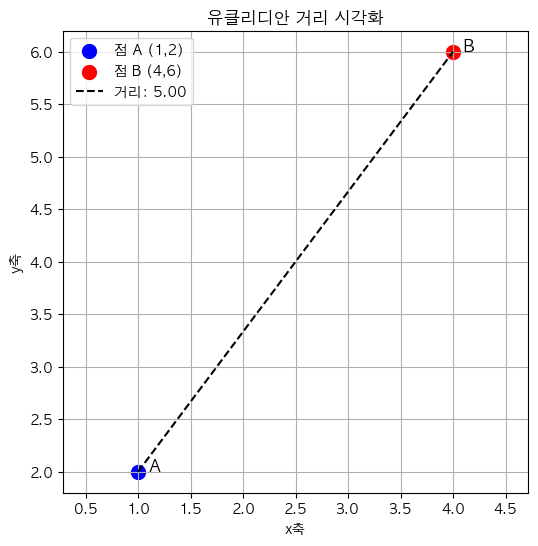

In [4]:

from scipy.spatial.distance import euclidean

# 두 벡터 정의
x = np.array([1, 2])
y = np.array([4, 6])

# 거리 계산
d_euclidean = euclidean(x, y)
print("유클리디안 거리:", d_euclidean)

# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(*x, color='blue', s=100, label='점 A (1,2)')
plt.scatter(*y, color='red', s=100, label='점 B (4,6)')

# 직선 그리기 (유클리디안 거리)
plt.plot([x[0], y[0]], [x[1], y[1]], 'k--', label=f'거리: {d_euclidean:.2f}')

# 점에 텍스트 표시
plt.text(x[0]+0.1, x[1], 'A', fontsize=12)
plt.text(y[0]+0.1, y[1], 'B', fontsize=12)

plt.title('유클리디안 거리 시각화')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()


2. 맨해튼 거리 (Manhattan, L1)  

맨해튼 거리는 두 점 간의 거리를 직선이 아닌 축(가로/세로) 방향으로만 이동해서 측정하는 거리이다.
도시의 격자 구조처럼 블록을 따라 이동하는 거리라고 해서 "택시 거리" 또는 "L1 거리"라고도 한다.
   
\begin{align*}
\text{Manhattan Distance:} \quad
d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
\end{align*}


   x=(1,2),y=(4,6)    
   d(x,y)=∣1−4∣+∣2−6∣=3+4=7


   | 분야        | 활용                           |
| --------- | ---------------------------- |
| 머신러닝   | KNN, KMeans (custom), 이상치 탐지 |
| 추천 시스템 | 사용자 간 유사도 계산                 |
| 경로 탐색  | 게임, 로봇 경로 계획에서 격자 기반 거리 측정   |

맨하튼 거리: 7


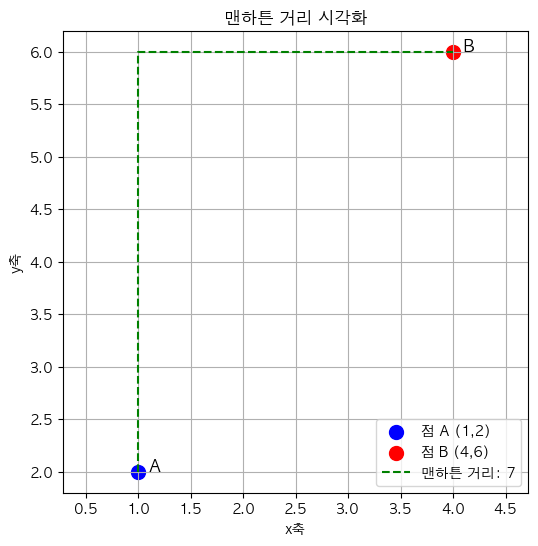

In [5]:

from scipy.spatial.distance import cityblock

# 두 점 정의
x = np.array([1, 2])
y = np.array([4, 6])

# 맨하튼 거리 계산
d_manhattan = cityblock(x, y)
print("맨하튼 거리:", d_manhattan)

# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(*x, color='blue', s=100, label='점 A (1,2)')
plt.scatter(*y, color='red', s=100, label='점 B (4,6)')

# 계단식 경로 (맨하튼 거리 경로)
plt.plot([x[0], x[0], y[0]], [x[1], y[1], y[1]], 'g--', label=f'맨하튼 거리: {d_manhattan}')

# 점에 텍스트 추가
plt.text(x[0]+0.1, x[1], 'A', fontsize=12)
plt.text(y[0]+0.1, y[1], 'B', fontsize=12)

plt.title('맨하튼 거리 시각화')
plt.xlabel('x축')
plt.ylabel('y축')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


3. 민코우스키 거리

민코우스키 거리는 두 점 사이의 일반화된 거리 측도이다.
다양한 거리 척도(예: 맨하튼, 유클리디안)를 포함하는 범용 공식이다.

$$
d(x, y) = \left( \sum\_{i=1}^{n}             | x\_i - y\_i                          | ^p \right)^{1/p}
$$


| 기호 / 요소                | 의미 설명       |
| -------------------------- | -----------------|
| $x = [x_1, x_2, ..., x_n]$ | 첫 번째 벡터 (n차원 포인트) |
| $y = [y_1, y_2, ..., y_n]$ | 두 번째 벡터           |   
| (\| x\_i - y\_i   \|)   | 각 차원의 절댓값 차이 |
| $p$                        | 거리의 차수 (하이퍼파라미터)  |  
| $\sum$                     | 전체 차원에 대한 합       |   
| $1/p$제곱                    | $p$ 제곱근으로 거리 조정   |




- 다양한 거리 척도로의 확장

|값                  | 이름       | 수식 형태                         | 설명                   |   |                  |
| ---------------------- | -------- | ----------------------------- | -------------------- | - | ---------------- |
| $p = 1$                | 맨하튼 거리   | $\sum (| x\_i - y\_i|)$ | 격자형 거리 (L1 norm) |
| $p = 2$                | 유클리디안 거리 | $\sqrt{ \sum (x_i - y_i)^2 }$ | 일반적인 직선 거리 (L2 norm) |   |                  |



- 예시 계산: 예시 계산: x=[1,2], 𝑦=[4,6]

| 거리 유형       | $p$ | 계산 결과  |  
| ----------- | --- | ------------------------------- |
| 맨하튼 거리      | 1   | (\| 1-4 \| + \| 2-6 \| = 3 + 4 = 7 ) |
| 유클리디안 거리    | 2   | $\sqrt{9 + 16} = \sqrt{25} = 5$ |     |   |     |               |
| 민코우스키 (p=3) | 3   | $(27 + 64)^{1/3} ≈ 4.4979$      |     |   |     |               |



p=1 (맨하튼): 7.0
p=2 (유클리디안): 5.0000
p=3 (민코우스키 p=3): 4.4979


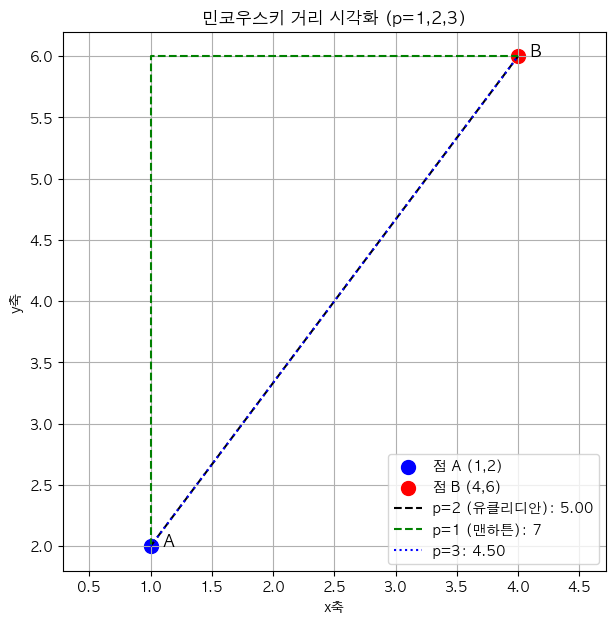

In [6]:

from scipy.spatial.distance import minkowski

# 두 점 정의
x = np.array([1, 2])
y = np.array([4, 6])

# 다양한 p 값에 따른 민코우스키 거리 계산
d_p1 = minkowski(x, y, p=1)   # 맨하튼 거리
d_p2 = minkowski(x, y, p=2)   # 유클리디안 거리
d_p3 = minkowski(x, y, p=3)

print(f"p=1 (맨하튼): {d_p1}")
print(f"p=2 (유클리디안): {d_p2:.4f}")
print(f"p=3 (민코우스키 p=3): {d_p3:.4f}")

# 시각화
plt.figure(figsize=(7, 7))
plt.scatter(*x, color='blue', s=100, label='점 A (1,2)')
plt.scatter(*y, color='red', s=100, label='점 B (4,6)')

# 유클리디안 거리 (직선)
plt.plot([x[0], y[0]], [x[1], y[1]], 'k--', label=f'p=2 (유클리디안): {d_p2:.2f}')

# 맨하튼 거리 경로
plt.plot([x[0], x[0], y[0]], [x[1], y[1], y[1]], 'g--', label=f'p=1 (맨하튼): {d_p1:.0f}')

# 민코우스키 p=3 표시 (점선은 같지만 거리 수치만 표시)
plt.plot([x[0], y[0]], [x[1], y[1]], 'b:', label=f'p=3: {d_p3:.2f}')

# 점에 라벨
plt.text(x[0]+0.1, x[1], 'A', fontsize=12)
plt.text(y[0]+0.1, y[1], 'B', fontsize=12)

plt.title('민코우스키 거리 시각화 (p=1,2,3)')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()


4. 코사인 거리 (Cosine Distance)

코사인 거리는 두 벡터의 **방향 차이(각도)**를 기준으로 측정하는 거리이다.
벡터의 크기(길이)가 아니라 방향이 얼마나 유사한지를 평가한다.

- 코사인 유사도는 두 벡터 사이의 코사인 각도를 측정 (1이면 동일 방향, 0이면 직각)

- 코사인 거리는 이를 거리로 바꾸어:  cosine distance = 1 − cosine similarity
  \begin{align*}
\text{Cosine Distance:} \quad
d(x, y) = 1 - \frac{ \sum_{i=1}^{n} x_i y_i }{ \sqrt{\sum_{i=1}^{n} x_i^2} \cdot \sqrt{\sum_{i=1}^{n} y_i^2} }
\end{align*}




\begin{align*}
\text{x=(1,0),𝑦=(0,1)}\\
\text{cosine similarity} &= \frac{1 \cdot 0 + 0 \cdot 1}{\sqrt{1^2 + 0^2} \cdot \sqrt{0^2 + 1^2}} = 0 \\
\Rightarrow \quad \text{cosine distance} &= 1 - 0 = 1
\end{align*}

- 특징

| 항목           | 설명                                      |
| ------------ | --------------------------------------- |
|  방향 중심     | 크기보다는 방향이 중요할 때 사용(방향 중심, 크기는 무시 )                      |
|적용 시점 | 고차원 희소 벡터 (텍스트, 이미지 임베딩 등) |
|  텍스트/문서 분석 | 단어 수(빈도)는 다르지만 의미가 비슷한 경우 유용            |
|  정규화 필요 없음 | 벡터 크기에 영향 받지 않음                         |
| 범위        | 유사도: -1 \~ 1 / 거리: 0 (같은 방향) \~ 2 (정반대) |
| 비적합         | 수치 기반 데이터에서 위치(좌표)가 중요한 경우            |





- 활용 분야  

| 분야             | 활용 예시                                       |
| -------------- | ------------------------------------------- |
| 자연어처리 (NLP) | 문서 간 의미 비교 (TF-IDF)                         |
| 추천 시스템      | 사용자-상품 유사도                                  |
| 클러스터링       | `DBSCAN(metric='cosine')`, `KMeans` (간접 사용) |

 ![삼각비표](https://mblogthumb-phinf.pstatic.net/MjAyMDA2MDNfMTc0/MDAxNTkxMTY5NzY5Nzg1.yyW09eUp9UFgCL93hMuhRffewFieglZ-9e1WwOcglpwg.x1dtvXZChXFn-riisWIYJnTB4Ee67dp__2o7Pnr1r6Mg.JPEG.minsuya8/2020-06-03_15;59;57.JPEG?type=w800)


Cosine Similarity: 0.7071
Cosine Distance  : 0.2929


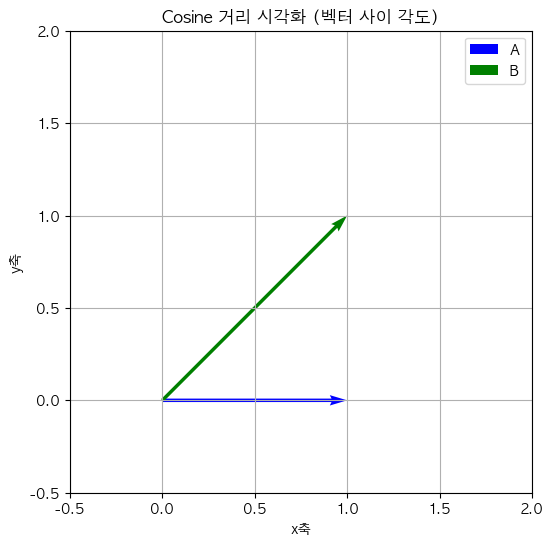

In [7]:

from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

# 두 벡터 정의
A = np.array([1, 0])
B = np.array([1, 1])

# 코사인 유사도 및 거리 계산
cos_sim = cosine_similarity([A], [B])[0][0]
cos_dist = cosine_distances([A], [B])[0][0]

print(f"Cosine Similarity: {cos_sim:.4f}")
print(f"Cosine Distance  : {cos_dist:.4f}")

# 시각화
plt.figure(figsize=(6, 6))
origin = np.array([0, 0])

# 벡터 화살표 그리기
plt.quiver(*origin, *A, angles='xy', scale_units='xy', scale=1, color='blue', label='A')
plt.quiver(*origin, *B, angles='xy', scale_units='xy', scale=1, color='green', label='B')

# 설정
plt.title("Cosine 거리 시각화 (벡터 사이 각도)")
plt.xlim(-0.5, 2)
plt.ylim(-0.5, 2)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.xlabel('x축')
plt.ylabel('y축')
plt.show()


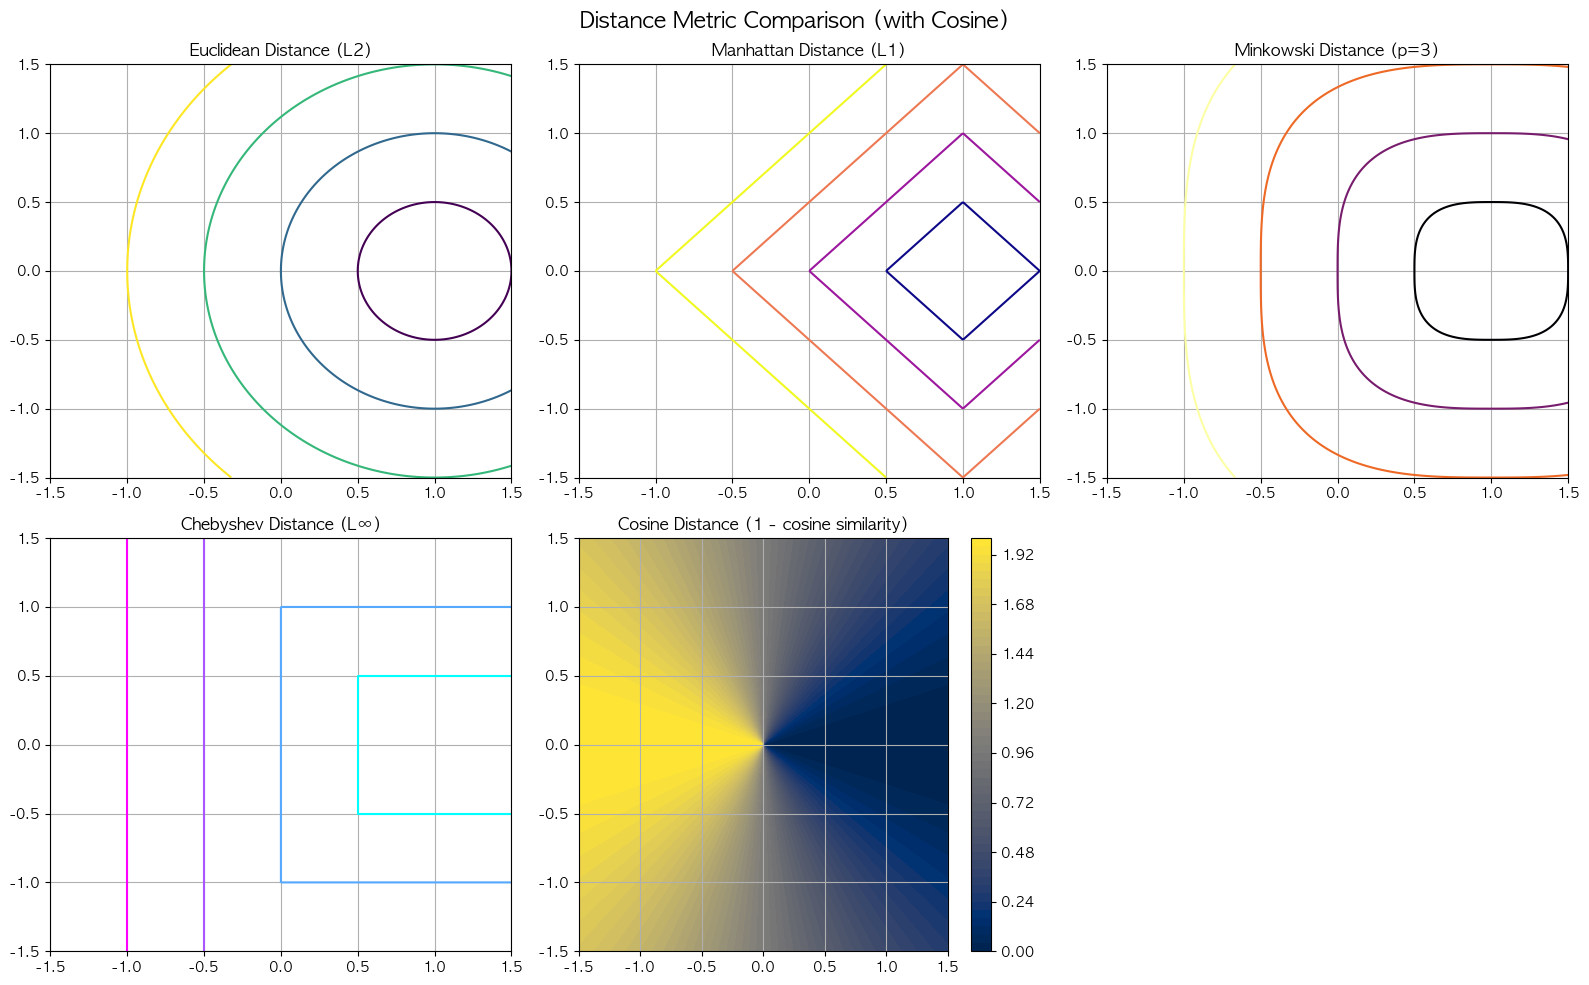

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 중심점 (기준 벡터)
center = np.array([1, 0])  # 코사인은 방향이 중요하므로 (1, 0)로 설정

# 좌표 범위
x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x, y)

# 거리 함수들
def euclidean(x, y):
    return np.sqrt((x - center[0])**2 + (y - center[1])**2)

def manhattan(x, y):
    return np.abs(x - center[0]) + np.abs(y - center[1])

def minkowski(x, y, p=3):
    return ((np.abs(x - center[0])**p + np.abs(y - center[1])**p))**(1/p)


def cosine(x, y):
    xvec = np.stack([x, y], axis=-1)
    norm_xvec = np.linalg.norm(xvec, axis=-1)
    dot = xvec[..., 0]*center[0] + xvec[..., 1]*center[1]
    cosine_similarity = dot / (norm_xvec * np.linalg.norm(center) + 1e-10)
    return 1 - cosine_similarity  # 코사인 거리


def chebyshev(x, y):
    return np.maximum(np.abs(x - center[0]), np.abs(y - center[1]))



# 그래프 설정
fig, axs = plt.subplots(2, 3, figsize=(16, 10))
levels = [0.5, 1, 1.5, 2]

# Euclidean
axs[0, 0].contour(X, Y, euclidean(X, Y), levels=levels, cmap='viridis')
axs[0, 0].set_title('Euclidean Distance (L2)')
axs[0, 0].grid(True)

# Manhattan
axs[0, 1].contour(X, Y, manhattan(X, Y), levels=levels, cmap='plasma')
axs[0, 1].set_title('Manhattan Distance (L1)')
axs[0, 1].grid(True)

# Minkowski (p=3)
axs[0, 2].contour(X, Y, minkowski(X, Y, p=3), levels=levels, cmap='inferno')
axs[0, 2].set_title('Minkowski Distance (p=3)')
axs[0, 2].grid(True)

# Chebyshev
axs[1, 0].contour(X, Y, chebyshev(X, Y), levels=levels, cmap='cool')
axs[1, 0].set_title('Chebyshev Distance (L∞)')
axs[1, 0].grid(True)

# Cosine
cs = axs[1, 1].contourf(X, Y, cosine(X, Y), levels=50, cmap='cividis')
axs[1, 1].set_title('Cosine Distance (1 - cosine similarity)')
axs[1, 1].grid(True)
fig.colorbar(cs, ax=axs[1, 1])

# 빈칸 제거
axs[1, 2].axis('off')

plt.suptitle('Distance Metric Comparison (with Cosine)', fontsize=16)
plt.tight_layout()
plt.show()
